# Sentiment Analysis using NLP

## Objective

To perform sentiment analysis on textual reviews using Natural Language Processing (NLP) techniques. The notebook includes data preprocessing, model training, evaluation, and insights.

## Import Libraries

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

## Upload Dataset

In [20]:


from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


## Load Dataset

In [21]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Dataset Information

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [23]:
df.columns

Index(['review', 'sentiment'], dtype='object')

## Data Preprocessing

In [24]:
# Check missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [25]:
# Remove missing values
df = df.dropna()

print(df.shape)

(50000, 2)


## Feature Selection

In [26]:
X = df["review"]
y = df["sentiment"]

## Feature Extraction

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

## Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 101895)
Testing Data: (10000, 101895)


## Model Training

In [29]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Prediction

In [30]:
y_pred = model.predict(X_test)

## Model Evaluation

In [31]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.8487

Classification Report:

              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      4961
    positive       0.87      0.82      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



## Confusion Matrix

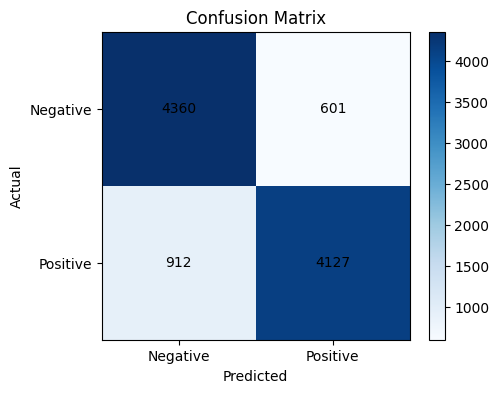

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Negative","Positive"])
plt.yticks([0,1], ["Negative","Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Conclusion

This project successfully performed sentiment analysis on movie reviews using Natural Language Processing (NLP). The text data was converted into numerical features using CountVectorizer, and a Multinomial Naive Bayes model was trained to classify reviews as positive or negative. The model achieved good accuracy, showing that machine learning can effectively analyze textual sentiment.